# Grammar Scoring Engine for Spoken English
### Whisper transcripts + grammar features + audio embeddings → Ridge regression

**Task.** Predict a continuous grammar score (mean opinion score on a 1–5 rubric) from a 45–60 s `.wav`
recording of spoken English. Leaderboard metrics: RMSE and Pearson correlation.

## Results at a glance

| | RMSE | Pearson | MAE | R² |
|---|---|---|---|---|
| Baseline: always predict the training mean | 1.014 | – | 0.876 | 0.00 |
| **Training data (final model fitted on all 732 clips) — required** | **0.333** | 0.949 | 0.257 | 0.892 |
| **5-fold cross-validation (realistic estimate)** | **0.535** | **0.850** | 0.410 | 0.721 |
| Public leaderboard (≈60 % of the 216 test clips) | 0.3846 | | | |

The model halves the error of the mean-prediction baseline and explains about 72 % of the variance in
grammar scores on clips it has not seen. Training RMSE is lower than CV RMSE because the model has
seen those clips; the cross-validated value is the honest estimate.

## Approach

Grammar lives in the words a speaker chooses, but *how* something is said (hesitation, fluency,
pronunciation) is also strongly related to the score. Each recording is therefore described in two ways:
(1) it is transcribed with Whisper and the transcript is analysed with grammar tools and text embeddings;
(2) two pretrained speech models turn the audio itself into fixed-length embeddings. All feature blocks
are standardised, weighted equally and fed to a Ridge regression, evaluated with stratified 5-fold
cross-validation.

## Pipeline

```
                ┌─► Whisper small.en ASR (prompted to keep fillers and errors) ─► transcript + ASR confidence
                │        ├─► CoLA grammar model (RoBERTa): sentence acceptability scores + embedding  [4 + 768]
                │        ├─► LanguageTool: grammar errors per word                                    [2]
                │        ├─► fluency & complexity: speech rate, fillers, repetitions, sentence length  [15]
                │        └─► general sentence embedding (all-mpnet-base-v2)                           [768]
.wav (16 kHz) ──┤
                ├─► wav2vec2-base, layer 8, whole clip, mean + std over time                          [1536]
                └─► Whisper-small encoder, layer 9 (chosen by CV), 20 s chunks, mean + std            [1536]

4,629 features ─► standardise ─► equal weight per block ─► Ridge (alpha tuned inside each fold) ─► score in [1, 5]
```

## Notebook structure

| Section | Content |
|---|---|
| 1–2 | Configuration, data loading |
| 3 | Speech recognition with Whisper, transcript examples, **exploratory analysis** |
| 4–6 | Text features: fluency/complexity, grammar (CoLA, LanguageTool), sentence embedding |
| 7 | Audio embeddings: wav2vec2 and Whisper encoder |
| 8 | Combining feature blocks, **handling of score-0 clips**, **Whisper layer selection** |
| 9–10 | Cross-validation set-up, **ablation study** (which features help) |
| 11 | Cross-validated evaluation, **residual and error analysis** |
| 12 | Final model and **training RMSE (required)** |
| 13–14 | Test predictions, `submission.csv`, results summary |
| 15 | **Report** |

> **To run:** Kaggle notebook with the competition data attached, **Accelerator = GPU**, **Internet = On**,
> then *Run All* (about 1–1.5 h; transcription is the slowest step). All randomness is seeded.

In [1]:
# Install the two packages not included in the Kaggle image: Whisper (speech recognition) and LanguageTool.
!pip install -q openai-whisper language_tool_python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 30.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.2/63.2 kB 3.6 MB/s eta 0:00:00


In [2]:
# Imports: numerical/data libraries, plotting, audio loading, PyTorch, scikit-learn and Hugging Face transformers.
import os, re, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import soundfile as sf
import torch
import joblib
from tqdm.auto import tqdm
from scipy.stats import pearsonr, spearmanr

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from transformers import (AutoTokenizer, AutoModel, AutoFeatureExtractor,
                          AutoModelForSequenceClassification)
from transformers.utils import logging as hf_logging
import whisper

hf_logging.set_verbosity_error()
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")

## 1. Configuration

In [3]:
# ---------------- paths ----------------
DATA_DIR = None          # e.g. "/kaggle/input/<competition-slug>"; None = search under /kaggle/input
INPUT_ROOT = Path(DATA_DIR) if DATA_DIR else Path("/kaggle/input")
WORK_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path("./outputs")
WORK_DIR.mkdir(parents=True, exist_ok=True)
FILE_COL, LABEL_COL = None, None     # None = auto-detect

# ---------------- audio ----------------
SAMPLE_RATE  = 16_000
TRIM_SILENCE = True
TRIM_TOP_DB  = 30

# ---------------- speech recognition ----------------
WHISPER_MODEL  = "small.en"   # "medium.en" is more accurate but ~2-3x slower
# The prompt shows Whisper a disfluent style, which makes it keep fillers ("um", "uh")
# instead of producing a cleaned-up, grammatically "corrected" transcript.
WHISPER_PROMPT = "Umm, let me think like, hmm... Okay, here's what I'm, like, thinking. So, uh, I was, I was going there."

# ---------------- text models ----------------
TEXT_EMB_MODEL   = "sentence-transformers/all-mpnet-base-v2"
COLA_MODEL       = "textattack/roberta-base-CoLA"   # RoBERTa fine-tuned to judge grammatical acceptability
USE_LANGUAGETOOL = True                             # needs Java; skipped automatically if unavailable

# ---------------- audio embeddings (from the wav2vec2 notebook) ----------------
W2V_MODEL   = "facebook/wav2vec2-base"
AUDIO_LAYER = 8                                     # best layer found in the wav2vec2 notebook
W2V_CACHE   = "feats_{split}_wav2vec2-base_full_mean_std_trim1.npz"

# ---------------- Whisper encoder embeddings (from the Whisper encoder + SVR notebook) ----------------
USE_WHISPER_ENC   = True
WENC_MODEL        = "openai/whisper-small"
WENC_CHUNK_SEC    = 20.0
WENC_CACHE        = "feats_{split}_whisper-small_c20_o0_mean_std_trim1.npz"
WHISPER_ENC_LAYER = None      # None = choose the best layer by cross-validation in Section 8

# ---------------- training data ----------------
# 37 training clips have score 0, which is not on the 1-5 rubric: they form one separate batch
# (audio_5037-audio_5073, almost all exactly 60.07 s, little or no intelligible speech).
# No test clip looks like them (Section 8 checks this), so they are left out of training.
DROP_ZERO_LABELS = True

# ---------------- validation ----------------
N_SPLITS = 5
SEED     = 42
ALPHAS   = np.logspace(-4, 4, 41)

np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE, "| work dir:", WORK_DIR)

device: cuda | work dir: /kaggle/working


## 2. Load the data and locate the audio files

In [4]:
# Locate train.csv / test.csv, detect the file-name and label columns, map every file name to its .wav path,
# and define helpers for loading audio and finding cached files.
train_csvs = sorted(INPUT_ROOT.rglob("train.csv"))
assert train_csvs, f"train.csv not found under {INPUT_ROOT}. Set DATA_DIR in the config cell."
CSV_DIR = train_csvs[0].parent
train_df = pd.read_csv(train_csvs[0])
test_df  = pd.read_csv(CSV_DIR / "test.csv" if (CSV_DIR / "test.csv").exists()
                       else sorted(INPUT_ROOT.rglob("test.csv"))[0])

def detect_cols(df):
    file_col = next((c for c in df.columns if df[c].dtype == object), df.columns[0])
    label_col = next((c for c in df.columns
                      if c != file_col and pd.api.types.is_numeric_dtype(df[c])), None)
    return file_col, label_col

auto_file, auto_label = detect_cols(train_df)
FILE_COL, LABEL_COL = FILE_COL or auto_file, LABEL_COL or auto_label
print(f"file column: '{FILE_COL}' | label column: '{LABEL_COL}' | train {train_df.shape} | test {test_df.shape}")

def norm_name(name):
    name = Path(str(name)).name
    return name[:-4] if name.lower().endswith(".wav") else name

wav_index = {}
for p in INPUT_ROOT.rglob("*"):
    if p.suffix.lower() == ".wav":
        wav_index.setdefault(norm_name(p.name), []).append(p)
print("wav files found:", sum(len(v) for v in wav_index.values()))

def resolve(name, split):
    cands = wav_index.get(norm_name(name), [])
    if not cands:
        raise FileNotFoundError(f"No .wav for '{name}'")
    pref = [p for p in cands if split in str(p).lower()]
    return str((pref or cands)[0])

train_df["path"] = [resolve(n, "train") for n in train_df[FILE_COL]]
test_df["path"]  = [resolve(n, "test")  for n in test_df[FILE_COL]]
y_train = train_df[LABEL_COL].to_numpy(dtype=np.float64)
CLIP_MIN, CLIP_MAX = max(0.0, y_train.min()), min(5.0, y_train.max())
print("label range:", y_train.min(), "-", y_train.max())

def load_audio(path):
    """16 kHz mono float32, silence trimmed at both ends, peak-normalised."""
    wav, _ = librosa.load(path, sr=SAMPLE_RATE, mono=True)
    if TRIM_SILENCE:
        wav, _ = librosa.effects.trim(wav, top_db=TRIM_TOP_DB)
    peak = np.abs(wav).max()
    return (0.95 * wav / peak if peak > 0 else wav).astype(np.float32)

def find_cached(filename):
    """Look for a cached file in the working directory or in any attached input (e.g. a previous notebook's output)."""
    for root in (WORK_DIR, Path("/kaggle/input")):
        if root.exists():
            hits = sorted(root.rglob(filename))
            if hits:
                return hits[0]
    return None

file column: 'filename' | label column: 'label' | train (769, 2) | test (216, 2)
wav files found: 985
label range: 0.0 - 5.0


## 3. Speech recognition with Whisper
Settings chosen to keep the transcript faithful to what was actually said:
* **Disfluent initial prompt** → Whisper keeps fillers and false starts.
* `condition_on_previous_text=False` → each 30 s window is decoded independently, which avoids
  hallucinated repetitions carrying over between windows.
* Low temperature with fallback → deterministic output, with retries only when decoding fails.

Besides the text, Whisper's own confidence (`avg_logprob`, `no_speech_prob`, `compression_ratio`) is
kept as features: unclear or hesitant speech gets lower confidence. Transcripts are cached to CSV.

In [5]:
# Transcribe every recording with Whisper (cached to CSV) and keep Whisper's confidence statistics as features.
def transcribe_split(df, split):
    fname = f"transcripts_{split}_{WHISPER_MODEL}.csv"
    cached = find_cached(fname)
    if cached is not None:
        out = pd.read_csv(cached)
        print(f"loaded cached transcripts: {cached}")
        return out
    global asr
    if "asr" not in globals():
        asr = whisper.load_model(WHISPER_MODEL, device=DEVICE)
    rows = []
    for name, path in tqdm(zip(df[FILE_COL], df.path), total=len(df), desc=f"transcribing {split}"):
        wav = load_audio(path)
        r = asr.transcribe(wav, language="en", initial_prompt=WHISPER_PROMPT,
                           condition_on_previous_text=False, temperature=(0.0, 0.2, 0.4),
                           fp16=(DEVICE == "cuda"), verbose=None)
        segs = r.get("segments", [])
        rows.append({
            FILE_COL: name,
            "text": r["text"].strip(),
            "duration": len(wav) / SAMPLE_RATE,
            "asr_avg_logprob": np.mean([s["avg_logprob"] for s in segs]) if segs else np.nan,
            "asr_no_speech_prob": np.mean([s["no_speech_prob"] for s in segs]) if segs else np.nan,
            "asr_compression_ratio": np.mean([s["compression_ratio"] for s in segs]) if segs else np.nan,
        })
    out = pd.DataFrame(rows)
    out.to_csv(WORK_DIR / fname, index=False)
    print(f"saved {fname}")
    return out

t0 = time.time()
tr_train = transcribe_split(train_df, "train")
tr_test  = transcribe_split(test_df,  "test")
print(f"transcription done in {time.time() - t0:.0f} s")

if "asr" in globals():          # free GPU memory for the next models
    del asr
    torch.cuda.empty_cache()

# keep the same row order as train_df / test_df
tr_train = train_df[[FILE_COL]].merge(tr_train, on=FILE_COL, how="left")
tr_test  = test_df[[FILE_COL]].merge(tr_test, on=FILE_COL, how="left")
tr_train["text"] = tr_train["text"].fillna("").astype(str)
tr_test["text"]  = tr_test["text"].fillna("").astype(str)
print("empty transcripts (train/test):", (tr_train.text == "").sum(), (tr_test.text == "").sum())

100%|████████████████████████████████████████| 461M/461M [00:02<00:00, 221MiB/s]


transcribing train:   0%|          | 0/769 [00:00<?, ?it/s]

saved transcripts_train_small.en.csv


transcribing test:   0%|          | 0/216 [00:00<?, ?it/s]

saved transcripts_test_small.en.csv
transcription done in 2272 s
empty transcripts (train/test): 4 0


### What do transcripts look like at each score level?
If Whisper were "cleaning up" the speech, low-scoring transcripts would look as fluent as high-scoring ones.

In [6]:
# Show one random transcript per score level to check that fillers and grammar mistakes are kept.
pd.set_option("display.max_colwidth", 400)
examples = (tr_train.assign(score=y_train)
            .groupby(np.round(y_train).astype(int), group_keys=False)
            .apply(lambda g: g.sample(1, random_state=SEED)))
display(examples[["score", "text"]].sort_values("score"))

,score,text
326,0.0,"Okay, I still like to buy a farm, unfastable. They will sell, but, uh, actually it's really great. The young people are very beautiful, beautiful each one, very important to the theme of the farm that we have mentioned. The ones for the fastables, the trees, the working trees, they were all very, very fine. really burn my hair very well and it will definitely come back again. I will recommend ..."
423,1.0,"As a young child, one of the most exacting places to be was the playground. It was a place with the rules of classrooms and the structure and environment of schools has been played well in our, like, the school days. We need to play very good sports in our playgrounds and we have lots of injuries in that our school time. So, at the time, just we played a lot of things. Even we have got injurie..."
89,2.0,"My best day was when I'm in childhood with my fam, with my family, I went to a tour. On that day, we enjoyed very lot with my family members. And we played game, we played more games. And we can spend more time on that place. If that moments are, are very special for me, When I thinking that I would be very very happy. All my family members makes that day very special. life has their best days."
679,3.0,"Today my topic is about describing the scene of a crowded market. Here, I can say in my YouTube list, there is a market which contains a huge number of people and huge number of sellers. There are some members will be selling the vegetables or something else in the market. And the buyers will be asking the amount for that and they'll be asking for amount for 1 kg but they're not going to take ..."
79,3.5,"My topic is about the sale of a crowded market. Here, the sellers will sell the goods and the buyers will buy the products. Her goods are products and nothing, but okay, both are same. Here, the sellers will sell the goods to the buyer and the buyers will buy the goods from the sellers here the sounds we hear from the market are very noisy and sometimes we will call it a this is an market or a..."
283,5.0,"A journey or travel experience that, I guess, is my favorite place to visit is Dominican Republic. You get there by plane. It takes about three and a half hours from the east coast to get there. Local foods or dishes from this place that I love is definitely the rotisserie chicken, the barbecue chicken, any sort of chicken from out there is amazing actually. The local beer is great as well. Th..."


**What the examples show:** The transcripts keep fillers ("uh", "um"), repetitions and errors such as
"we enjoyed very lot" or "When I thinking", so the grammar features can see the speaker's mistakes. The
score-0 example reads like fluent but incoherent text, an early sign that score-0 clips are a separate
case (see Section 8).

### Exploratory analysis

Number of training clips per grammar score:
0.0     37
1.0      1
1.5      3
2.0    102
2.5     79
3.0    174
3.5     64
4.0    124
4.5     52
5.0    133


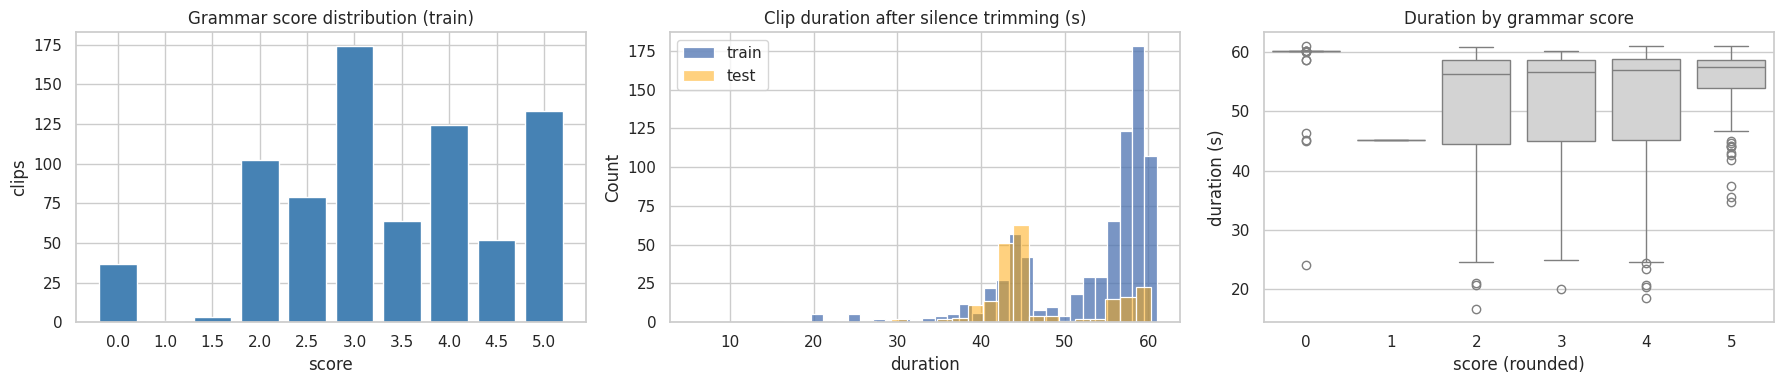

In [7]:
# Exploratory analysis of the labels and clip durations (all 769 training clips, before any filtering).
# The duration is measured after leading/trailing silence was trimmed.
score_counts = pd.Series(y_train).value_counts().sort_index()
print("Number of training clips per grammar score:")
print(score_counts.to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].bar(score_counts.index.astype(str), score_counts.values, color="steelblue")
axes[0].set_title("Grammar score distribution (train)"); axes[0].set_xlabel("score"); axes[0].set_ylabel("clips")
sns.histplot(tr_train.duration, bins=30, ax=axes[1], label="train")
sns.histplot(tr_test.duration, bins=30, ax=axes[1], color="orange", alpha=0.5, label="test")
axes[1].set_title("Clip duration after silence trimming (s)"); axes[1].legend()
sns.boxplot(x=np.round(y_train).astype(int), y=tr_train.duration, ax=axes[2], color="lightgray")
axes[2].set_title("Duration by grammar score"); axes[2].set_xlabel("score (rounded)"); axes[2].set_ylabel("duration (s)")
plt.tight_layout(); plt.show()

**Observations.**
* Scores are in steps of 0.5 (mean opinion scores). Most clips lie between 2 and 5; scores 1–1.5 are very
  rare (4 clips).
* **37 clips have score 0**, which is not on the 1–5 rubric. They are examined in Section 8.
* Over 90 % of train and test clips last 40–61 s after trimming silence, but test clips are somewhat shorter
  on average (median ≈ 45 s vs ≈ 57 s in train). Pooled embeddings and per-word rates do not depend on clip
  length, so this difference is handled by the feature design.

## 4. Interpretable fluency and complexity features
Simple, explainable measures computed from the transcript and timing:

| feature | what it captures |
|---|---|
| `n_words`, `speech_rate` | amount of speech, words per second |
| `n_sentences`, `mean/max/std_sent_len` | sentence length and complexity |
| `type_token_ratio`, `root_ttr`, `mean_word_len` | vocabulary range |
| `filler_rate` | "um", "uh", "er" per word |
| `repetition_rate` | immediate word repetitions ("I I went") per word |
| `asr_*` | Whisper's confidence in what it heard |

In [8]:
# Interpretable fluency and complexity features computed from each transcript and its duration.
FILLERS = {"um", "umm", "uh", "uhh", "uhm", "er", "erm", "ah", "ahh", "hmm", "hm", "mm", "mhm", "eh"}

def tokenize(text):
    return re.findall(r"[a-z']+", text.lower())

def split_sentences(text):
    parts = re.split(r"(?<=[.!?])\s+", text.strip())
    return [p for p in parts if tokenize(p)]

def basic_features(tr):
    rows = []
    for text, dur in zip(tr.text, tr.duration):
        words = tokenize(text)
        n = len(words)
        content = [w for w in words if w not in FILLERS]
        sent_lens = [len(tokenize(s)) for s in split_sentences(text)] or [0]
        rows.append({
            "n_words": n,
            "speech_rate": n / max(dur, 1e-6),
            "n_sentences": len(split_sentences(text)),
            "mean_sent_len": float(np.mean(sent_lens)),
            "max_sent_len": float(np.max(sent_lens)),
            "std_sent_len": float(np.std(sent_lens)),
            "type_token_ratio": len(set(content)) / max(len(content), 1),
            "root_ttr": len(set(content)) / np.sqrt(max(len(content), 1)),
            "mean_word_len": float(np.mean([len(w) for w in content])) if content else 0.0,
            "filler_rate": sum(w in FILLERS for w in words) / max(n, 1),
            "repetition_rate": sum(a == b for a, b in zip(words, words[1:])) / max(n, 1),
        })
    out = pd.DataFrame(rows)
    for c in ["duration", "asr_avg_logprob", "asr_no_speech_prob", "asr_compression_ratio"]:
        out[c] = tr[c].to_numpy()
    return out

hand_train = basic_features(tr_train)
hand_test  = basic_features(tr_test)

## 5. Grammar features
### 5a. Grammatical acceptability model (CoLA)
A RoBERTa model fine-tuned on **CoLA** (Corpus of Linguistic Acceptability), where each sentence is
labelled grammatical or ungrammatical. Each transcript sentence gets a probability of being acceptable. Per recording we keep the mean, minimum, spread and share of sentences judged unacceptable.
The model's mean-pooled hidden states over the whole transcript form a second, grammar-oriented
embedding.

In [9]:
# Grammar features from a RoBERTa model fine-tuned on CoLA (grammatical acceptability):
# per-sentence acceptability statistics and a mean-pooled embedding of the whole transcript.
try:
    cola_tok = AutoTokenizer.from_pretrained(COLA_MODEL)
except Exception:
    cola_tok = AutoTokenizer.from_pretrained("roberta-base")
cola = AutoModelForSequenceClassification.from_pretrained(COLA_MODEL).to(DEVICE).eval()

@torch.inference_mode()
def cola_probs(sentences, bs=64):
    """Softmax over the two CoLA classes for each sentence."""
    out = []
    for i in range(0, len(sentences), bs):
        enc = cola_tok(sentences[i:i + bs], padding=True, truncation=True, max_length=128,
                       return_tensors="pt").to(DEVICE)
        out.append(torch.softmax(cola(**enc).logits.float(), dim=-1).cpu().numpy())
    return np.concatenate(out) if out else np.zeros((0, 2))

# Check which output index means "acceptable" with a clear pair, instead of assuming it
check = cola_probs(["She has finished her homework.", "She have finish her homework yesterday tomorrow."])
ACCEPT_IDX = 1 if check[0, 1] > check[1, 1] else 0
print(f"acceptable class index = {ACCEPT_IDX} | P(acceptable): "
      f"correct = {check[0, ACCEPT_IDX]:.3f}, incorrect = {check[1, ACCEPT_IDX]:.3f}")

def cola_features(tr):
    sents, owner = [], []
    for i, text in enumerate(tr.text):
        for s in split_sentences(text):
            sents.append(s); owner.append(i)
    owner = np.array(owner)
    p = cola_probs(sents)[:, ACCEPT_IDX] if sents else np.array([])
    rows = []
    for i in range(len(tr)):
        pi = p[owner == i] if len(p) else np.array([])
        rows.append({
            "cola_mean": pi.mean() if len(pi) else np.nan,
            "cola_min": pi.min() if len(pi) else np.nan,
            "cola_std": pi.std() if len(pi) else np.nan,
            "cola_frac_unacceptable": (pi < 0.5).mean() if len(pi) else np.nan,
        })
    return pd.DataFrame(rows)

@torch.inference_mode()
def mean_pooled_embeddings(model, tokenizer, texts, max_len, bs=16):
    """Mean of the last hidden layer over real tokens, one vector per text."""
    out = []
    for i in tqdm(range(0, len(texts), bs), desc="embedding", leave=False):
        enc = tokenizer(list(texts[i:i + bs]), padding=True, truncation=True, max_length=max_len,
                        return_tensors="pt").to(DEVICE)
        h = model(**enc, output_hidden_states=True).hidden_states[-1].float()
        m = enc["attention_mask"].unsqueeze(-1).float()
        out.append(((h * m).sum(1) / m.sum(1).clamp_min(1)).cpu().numpy())
    return np.concatenate(out).astype(np.float32)

hand_train = pd.concat([hand_train, cola_features(tr_train)], axis=1)
hand_test  = pd.concat([hand_test,  cola_features(tr_test)],  axis=1)
cola_emb_train = mean_pooled_embeddings(cola, cola_tok, tr_train.text.tolist(), 512)
cola_emb_test  = mean_pooled_embeddings(cola, cola_tok, tr_test.text.tolist(), 512)
del cola; torch.cuda.empty_cache()
print("CoLA embeddings:", cola_emb_train.shape)

config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

acceptable class index = 1 | P(acceptable): correct = 0.966, incorrect = 0.123


embedding:   0%|          | 0/49 [00:00<?, ?it/s]

embedding:   0%|          | 0/14 [00:00<?, ?it/s]

CoLA embeddings: (769, 768)


### 5b. LanguageTool grammar-error rate
A rule-based grammar checker. Only grammar-related matches are counted; spelling, capitalisation and
punctuation are ignored because they reflect the ASR output rather than the speaker.

In [10]:
# Rule-based grammar checking with LanguageTool: grammar-related errors per word.
IGNORED_LT = {"TYPOS", "CASING", "PUNCTUATION", "TYPOGRAPHY", "WHITESPACE"}

def languagetool_features(texts):
    try:
        import language_tool_python
        tool = language_tool_python.LanguageTool("en-US")
    except Exception as e:
        print("LanguageTool unavailable, skipping:", repr(e)[:200])
        return None
    rows = []
    for t in tqdm(texts, desc="LanguageTool"):
        matches = tool.check(t) if t else []
        cats = [str(getattr(m, "category", "")).upper() for m in matches]
        n = max(len(tokenize(t)), 1)
        rows.append({"lt_errors_per_word": sum(c not in IGNORED_LT for c in cats) / n,
                     "lt_grammar_per_word": sum(c == "GRAMMAR" for c in cats) / n})
    tool.close()
    return pd.DataFrame(rows)

if USE_LANGUAGETOOL:
    lt_train = languagetool_features(tr_train.text.tolist())
    lt_test  = languagetool_features(tr_test.text.tolist()) if lt_train is not None else None
    if lt_train is not None:
        hand_train = pd.concat([hand_train, lt_train], axis=1)
        hand_test  = pd.concat([hand_test,  lt_test],  axis=1)

# Missing values (e.g. an empty transcript) -> training median; no labels are involved
medians = hand_train.median()
hand_train, hand_test = hand_train.fillna(medians), hand_test.fillna(medians)
print("interpretable features:", list(hand_train.columns))

LanguageTool:   0%|          | 0/769 [00:00<?, ?it/s]

LanguageTool:   0%|          | 0/216 [00:00<?, ?it/s]

interpretable features: ['n_words', 'speech_rate', 'n_sentences', 'mean_sent_len', 'max_sent_len', 'std_sent_len', 'type_token_ratio', 'root_ttr', 'mean_word_len', 'filler_rate', 'repetition_rate', 'duration', 'asr_avg_logprob', 'asr_no_speech_prob', 'asr_compression_ratio', 'cola_mean', 'cola_min', 'cola_std', 'cola_frac_unacceptable', 'lt_errors_per_word', 'lt_grammar_per_word']


## 6. Sentence embedding of the transcript
`all-mpnet-base-v2` summarises the whole transcript in one 768-d vector (content, style and structure).

In [11]:
# General-purpose sentence embedding of each transcript (all-mpnet-base-v2, mean pooling).
emb_tok   = AutoTokenizer.from_pretrained(TEXT_EMB_MODEL)
emb_model = AutoModel.from_pretrained(TEXT_EMB_MODEL).to(DEVICE).eval()
text_emb_train = mean_pooled_embeddings(emb_model, emb_tok, tr_train.text.tolist(), 384)
text_emb_test  = mean_pooled_embeddings(emb_model, emb_tok, tr_test.text.tolist(), 384)
del emb_model; torch.cuda.empty_cache()
print("sentence embeddings:", text_emb_train.shape)

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

embedding:   0%|          | 0/49 [00:00<?, ?it/s]

embedding:   0%|          | 0/14 [00:00<?, ?it/s]

sentence embeddings: (769, 768)


## 7. Audio embeddings
Two pretrained speech models describe *how* the answer sounds:
* **wav2vec2-base** (self-supervised on audio only), layer 8, applied to the whole clip.
* **Whisper-small encoder** (trained to transcribe speech), applied to 20 s chunks; padding frames are removed and all real frames are pooled, so the vector does not depend on clip length.

Frame-level embeddings are summarised by their mean and standard deviation over time (1,536 numbers per model).

In [12]:
# Audio embeddings: wav2vec2 (layer 8, whole clip) and the Whisper-small encoder (all layers, 20 s chunks).
@torch.inference_mode()
def w2v_layer_features(df):
    fe = AutoFeatureExtractor.from_pretrained(W2V_MODEL)
    model = AutoModel.from_pretrained(W2V_MODEL).to(DEVICE).eval()
    feats = []
    for p in tqdm(df.path, desc="wav2vec2"):
        x = fe(load_audio(p), sampling_rate=SAMPLE_RATE, return_tensors="pt").input_values.to(DEVICE)
        h = model(x, output_hidden_states=True).hidden_states[AUDIO_LAYER][0].float()
        feats.append(torch.cat([h.mean(0), h.std(0)]).cpu().numpy())
    del model; torch.cuda.empty_cache()
    return np.stack(feats).astype(np.float32)

def audio_features(df, split):
    cached = find_cached(W2V_CACHE.format(split=split))
    if cached is not None:
        X = np.load(cached)["X"]
        if len(X) == len(df):
            print(f"loaded cached wav2vec2 features: {cached}")
            return X[:, AUDIO_LAYER]
    return w2v_layer_features(df)

audio_train = audio_features(train_df, "train")
audio_test  = audio_features(test_df,  "test")
print("audio features:", audio_train.shape)


@torch.inference_mode()
def whisper_encoder_all_layers(df):
    """Same features as the Whisper encoder notebook: 20 s chunks, padding frames removed,
    mean + std over all real frames of the clip, for every encoder layer -> (N, n_layers, 2d)."""
    from transformers import WhisperFeatureExtractor, WhisperModel
    dtype = torch.float16 if DEVICE == "cuda" else torch.float32
    fe  = WhisperFeatureExtractor.from_pretrained(WENC_MODEL)
    enc = WhisperModel.from_pretrained(WENC_MODEL, torch_dtype=dtype).get_encoder().to(DEVICE).eval()
    samples_per_frame, max_frames = fe.hop_length * 2, fe.nb_max_frames // 2
    size = int(WENC_CHUNK_SEC * SAMPLE_RATE)
    feats = []
    for p in tqdm(df.path, desc="Whisper encoder"):
        wav = load_audio(p)
        chunks = [wav[s:s + size] for s in range(0, len(wav), size)]
        if len(chunks) > 1 and len(chunks[-1]) < 2 * SAMPLE_RATE:
            chunks = chunks[:-1]
        x = fe(chunks, sampling_rate=SAMPLE_RATE, return_tensors="pt").input_features.to(DEVICE, dtype=dtype)
        hs = torch.stack(enc(x, output_hidden_states=True).hidden_states).float()   # (L, n_chunks, 1500, d)
        mask = torch.zeros(hs.shape[1], hs.shape[2], device=hs.device)
        for i, c in enumerate(chunks):
            mask[i, :min(max_frames, int(np.ceil(len(c) / samples_per_frame)))] = 1.0
        m, n = mask[None, :, :, None], mask.sum()
        mean = (hs * m).sum(dim=(1, 2)) / n
        std = ((((hs - mean[:, None, None, :]) ** 2) * m).sum(dim=(1, 2)) / n).clamp_min(1e-8).sqrt()
        feats.append(torch.cat([mean, std], dim=-1).cpu().numpy())
    del enc; torch.cuda.empty_cache()
    return np.stack(feats).astype(np.float32)

def whisper_encoder_features(df, split):
    cached = find_cached(WENC_CACHE.format(split=split))
    if cached is not None:
        X = np.load(cached)["X"]
        if len(X) == len(df):
            print(f"loaded cached Whisper encoder features: {cached}")
            return X
    X = whisper_encoder_all_layers(df)
    np.savez_compressed(WORK_DIR / WENC_CACHE.format(split=split), X=X)
    return X

if USE_WHISPER_ENC:
    wenc_train_all = whisper_encoder_features(train_df, "train")
    wenc_test_all  = whisper_encoder_features(test_df,  "test")
    print("Whisper encoder features (all layers):", wenc_train_all.shape)

preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.84k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  380MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  380MB            

...

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

Whisper encoder:   0%|          | 0/769 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

Whisper encoder:   0%|          | 0/216 [00:00<?, ?it/s]

Whisper encoder features (all layers): (769, 13, 1536)


## 8. Combine the feature blocks
**Score-0 clips.** The rubric runs from 1 to 5, but 37 training clips are scored 0. They are one
separate batch (consecutive IDs, almost all exactly 60.07 s long, little or no intelligible speech).
The cell below checks whether the test set contains anything similar; if not, these clips are left out
of training so the model concentrates on the 1–5 range it will actually be scored on.

The blocks have very different sizes (1,536 audio dimensions vs ~20 interpretable features). After
standardising every column, each block is divided by √(block size), so **every block carries the same
total variance**. Without this, Ridge's single penalty would let the largest block dominate.

In [13]:
# Assemble the feature blocks, remove the score-0 clips, pick the Whisper encoder layer by CV,
# and define the block-weighted Ridge pipeline.
BLOCK_DATA = {
    "audio":    (audio_train, audio_test),
    "text_emb": (text_emb_train, text_emb_test),
    "cola_emb": (cola_emb_train, cola_emb_test),
    "hand":     (hand_train.to_numpy(np.float32), hand_test.to_numpy(np.float32)),
}

class BlockScaler(BaseEstimator, TransformerMixin):
    """Standardise all columns, then scale each block by 1/sqrt(size) so blocks weigh equally."""
    def __init__(self, blocks):
        self.blocks = blocks                       # {name: (start, end)}
    def fit(self, X, y=None):
        self.scaler_ = StandardScaler().fit(X)
        return self
    def transform(self, X):
        Z = self.scaler_.transform(X)
        for start, end in self.blocks.values():
            Z[:, start:end] /= np.sqrt(end - start)
        return Z

def build(block_names):
    """Stack the chosen blocks; return train/test matrices and the column range of each block."""
    ranges, start = {}, 0
    for b in block_names:
        width = BLOCK_DATA[b][0].shape[1]
        ranges[b] = (start, start + width); start += width
    Xtr = np.hstack([BLOCK_DATA[b][0] for b in block_names])
    Xte = np.hstack([BLOCK_DATA[b][1] for b in block_names])
    return Xtr, Xte, ranges

def make_model(ranges):
    return Pipeline([("blocks", BlockScaler(ranges)), ("ridge", RidgeCV(alphas=ALPHAS))])

# ---- score-0 clips: compare with the test set, then (optionally) drop them from training
zero = y_train == 0
dur_train, dur_test = tr_train.duration.to_numpy(), tr_test.duration.to_numpy()
print(f"score-0 training clips: {zero.sum()} | of these, duration 60.0-60.1 s: "
      f"{np.sum(zero & (dur_train >= 60.0) & (dur_train <= 60.1))}")
print(f"test clips with duration 60.0-60.1 s: {np.sum((dur_test >= 60.0) & (dur_test <= 60.1))} | "
      f"test clips with an empty transcript: {(tr_test.text.str.strip() == '').sum()}")

if DROP_ZERO_LABELS and zero.any():
    KEEP = ~zero
    BLOCK_DATA = {b: (tr[KEEP], te) for b, (tr, te) in BLOCK_DATA.items()}
    train_df   = train_df[KEEP].reset_index(drop=True)
    tr_train   = tr_train[KEEP].reset_index(drop=True)
    hand_train = hand_train[KEEP].reset_index(drop=True)
    if USE_WHISPER_ENC:
        wenc_train_all = wenc_train_all[KEEP]
    y_train  = y_train[KEEP]
    CLIP_MIN = max(1.0, y_train.min())
    print(f"dropped {zero.sum()} score-0 clips -> {len(y_train)} training clips, predictions clipped to "
          f"[{CLIP_MIN}, {CLIP_MAX}]")

# ---- Whisper encoder block: choose the layer by cross-validation (same folds as Section 9)
if USE_WHISPER_ENC:
    folds_tmp = list(StratifiedKFold(N_SPLITS, shuffle=True, random_state=SEED)
                     .split(np.zeros(len(y_train)), np.round(y_train).astype(int)))
    def quick_rmse(X):
        oof = np.zeros(len(y_train))
        for tr, va in folds_tmp:
            m = Pipeline([("s", StandardScaler()), ("r", RidgeCV(alphas=np.logspace(-1, 6, 29)))]).fit(X[tr], y_train[tr])
            oof[va] = m.predict(X[va])
        return float(np.sqrt(np.mean((np.clip(oof, CLIP_MIN, CLIP_MAX) - y_train) ** 2)))
    if WHISPER_ENC_LAYER is None:
        layer_rmse = {l: quick_rmse(wenc_train_all[:, l]) for l in tqdm(range(wenc_train_all.shape[1]), desc="Whisper layer sweep")}
        WHISPER_ENC_LAYER = min(layer_rmse, key=layer_rmse.get)
        print("Whisper encoder CV RMSE by layer:", {l: round(v, 3) for l, v in layer_rmse.items()})
    print("Whisper encoder layer used:", WHISPER_ENC_LAYER)
    BLOCK_DATA["audio_whisper"] = (wenc_train_all[:, WHISPER_ENC_LAYER], wenc_test_all[:, WHISPER_ENC_LAYER])

for b, (tr, te) in BLOCK_DATA.items():
    print(f"{b:13s} train {tr.shape} | test {te.shape}")

score-0 training clips: 37 | of these, duration 60.0-60.1 s: 30
test clips with duration 60.0-60.1 s: 0 | test clips with an empty transcript: 0
dropped 37 score-0 clips -> 732 training clips, predictions clipped to [1.0, 5.0]


Whisper layer sweep:   0%|          | 0/13 [00:00<?, ?it/s]

Whisper encoder CV RMSE by layer: {0: 0.796, 1: 0.697, 2: 0.679, 3: 0.66, 4: 0.642, 5: 0.606, 6: 0.577, 7: 0.578, 8: 0.559, 9: 0.555, 10: 0.563, 11: 0.562, 12: 0.571}
Whisper encoder layer used: 9
audio         train (732, 1536) | test (216, 1536)
text_emb      train (732, 768) | test (216, 768)
cola_emb      train (732, 768) | test (216, 768)
hand          train (732, 21) | test (216, 21)
audio_whisper train (732, 1536) | test (216, 1536)


**Score-0 clips: why they were removed from training.**
* The rubric only defines scores 1–5; a 0 most likely means "not scorable".
* The 37 clips form one separate batch: consecutive IDs (`audio_5037`–`audio_5073`), **30 of 37 last exactly
  60.0–60.1 s**, four have empty transcripts and some Whisper transcripts are hallucinated.
* **No test clip** has that duration or an empty transcript, so learning to predict 0 does not help on the test
  set, while these extreme points would distort a linear model fitted to the 1–5 range.
* Measured on the same 732 clips, removing them improved CV RMSE from 0.573 to 0.565.

**Whisper encoder layer.** Every one of the 13 encoder layers was scored with Ridge on its own (plot below).
Early layers stay close to raw acoustics (RMSE 0.80 at layer 0); the middle-to-late layers 8–11, which encode
word-level content, are best. Layer 9 (RMSE 0.555) was used.

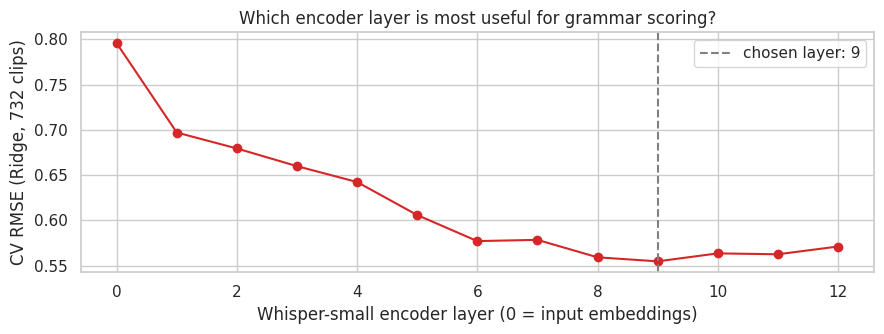

In [14]:
# Whisper encoder layer sweep (values computed in the cell above): CV RMSE of each layer used on its own.
if USE_WHISPER_ENC and "layer_rmse" in globals():
    plt.figure(figsize=(9, 3.5))
    plt.plot(list(layer_rmse.keys()), list(layer_rmse.values()), "o-", color="tab:red")
    plt.axvline(WHISPER_ENC_LAYER, color="gray", ls="--", label=f"chosen layer: {WHISPER_ENC_LAYER}")
    plt.xlabel("Whisper-small encoder layer (0 = input embeddings)"); plt.ylabel("CV RMSE (Ridge, 732 clips)")
    plt.title("Which encoder layer is most useful for grammar scoring?"); plt.legend()
    plt.tight_layout(); plt.show()

## 9. Validation set-up
Stratified 5-fold split with the same seed as the earlier notebooks. With the score-0 clips removed,
the folds contain 732 clips instead of 769, so compare earlier models on the same 732 clips
(the earlier text + audio model scored CV RMSE 0.573 on them).
`RidgeCV` chooses `alpha` inside each training fold, so out-of-fold scores are honest estimates.

In [15]:
# Stratified 5-fold split, evaluation metrics and the mean-prediction baseline.
FOLDS = list(StratifiedKFold(N_SPLITS, shuffle=True, random_state=SEED)
             .split(np.zeros(len(y_train)), np.round(y_train).astype(int)))

def metrics(y_true, y_pred):
    return {"RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
            "MAE": float(mean_absolute_error(y_true, y_pred)),
            "Pearson": float(pearsonr(y_true, y_pred)[0]),
            "Spearman": float(spearmanr(y_true, y_pred)[0]),
            "R2": float(r2_score(y_true, y_pred))}

def oof_predict(X, ranges):
    oof = np.zeros(len(y_train))
    for tr, va in FOLDS:
        m = make_model(ranges).fit(X[tr], y_train[tr])
        oof[va] = m.predict(X[va])
    return np.clip(oof, CLIP_MIN, CLIP_MAX)

baseline = {"RMSE": float(np.std(y_train)), "MAE": float(np.mean(np.abs(y_train - y_train.mean()))),
            "Pearson": np.nan, "Spearman": np.nan, "R2": 0.0}
print(f"Baseline (predict the mean): RMSE = {baseline['RMSE']:.4f}")

Baseline (predict the mean): RMSE = 1.0137


## 10. Which features help? (ablation)
Each feature set is evaluated with the same folds. This shows how much the transcript adds over audio
alone, and whether audio still adds something once the text is known.

ablation:   0%|          | 0/10 [00:00<?, ?it/s]

,n_features,RMSE,MAE,Pearson,Spearman,R2
feature set,,,,,,
Audio only (wav2vec2 L8),1536,0.6060,0.4657,0.8019,0.8001,0.6426
Interpretable features,21,0.7274,0.5773,0.6971,0.7035,0.4851
Sentence embedding,768,0.7782,0.6315,0.6410,0.6564,0.4108
CoLA embedding,768,0.6438,0.5178,0.7725,0.7824,0.5966
All text features,1557,0.6265,0.4981,0.7862,0.7971,0.6181
Text + audio,3093,0.5648,0.4396,0.8305,0.8299,0.6895
Audio only (Whisper encoder),1536,0.5549,0.4298,0.8375,0.8349,0.7004
Both audio blocks,3072,0.5605,0.4264,0.8335,0.8316,0.6943
Text + Whisper audio,3093,0.5467,0.4191,0.8422,0.8414,0.7091


Best feature set by CV RMSE: Text + both audio


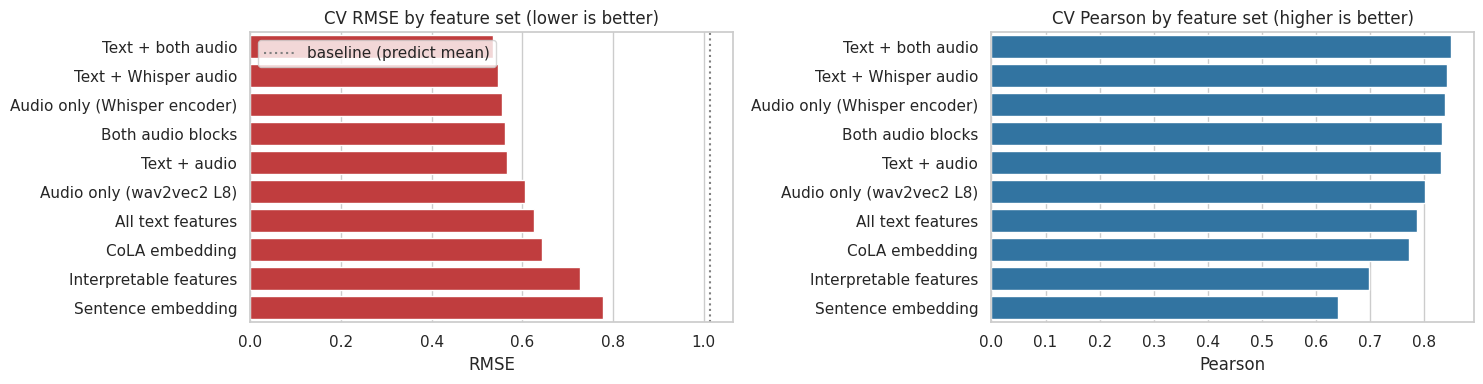

In [16]:
# Ablation: evaluate each combination of feature blocks with the same folds and pick the best one.
FEATURE_SETS = {
    "Audio only (wav2vec2 L8)":          ["audio"],
    "Interpretable features":            ["hand"],
    "Sentence embedding":                ["text_emb"],
    "CoLA embedding":                    ["cola_emb"],
    "All text features":                 ["text_emb", "cola_emb", "hand"],
    "Text + audio":                      ["audio", "text_emb", "cola_emb", "hand"],
}
if "audio_whisper" in BLOCK_DATA:
    FEATURE_SETS.update({
        "Audio only (Whisper encoder)":  ["audio_whisper"],
        "Both audio blocks":             ["audio", "audio_whisper"],
        "Text + Whisper audio":          ["audio_whisper", "text_emb", "cola_emb", "hand"],
        "Text + both audio":             ["audio", "audio_whisper", "text_emb", "cola_emb", "hand"],
    })

ablation, oof_by_set = [], {}
for name, blocks in tqdm(FEATURE_SETS.items(), desc="ablation"):
    Xtr, _, ranges = build(blocks)
    oof_by_set[name] = oof_predict(Xtr, ranges)
    ablation.append({"feature set": name, "n_features": Xtr.shape[1], **metrics(y_train, oof_by_set[name])})
ablation_df = pd.DataFrame(ablation).set_index("feature set")
display(ablation_df.round(4))
ablation_df.to_csv(WORK_DIR / "ablation.csv")

BEST_SET = ablation_df.RMSE.idxmin()
print("Best feature set by CV RMSE:", BEST_SET)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
order = ablation_df.sort_values("RMSE").index
sns.barplot(x=ablation_df.loc[order, "RMSE"], y=order, ax=axes[0], color="tab:red")
axes[0].axvline(baseline["RMSE"], color="gray", ls=":", label="baseline (predict mean)")
axes[0].set_title("CV RMSE by feature set (lower is better)"); axes[0].set_ylabel(""); axes[0].legend()
sns.barplot(x=ablation_df.loc[order, "Pearson"], y=order, ax=axes[1], color="tab:blue")
axes[1].set_title("CV Pearson by feature set (higher is better)"); axes[1].set_ylabel("")
plt.tight_layout(); plt.show()

**Reading the ablation (CV RMSE on 732 clips, lower is better).**

| Feature set | CV RMSE | Take-away |
|---|---|---|
| Sentence embedding only | 0.778 | General-purpose text meaning is a weak signal for grammar |
| Interpretable features only | 0.727 | 21 explainable numbers already carry real signal |
| CoLA embedding only | 0.644 | A *grammar-tuned* text representation is far better than a general one |
| wav2vec2 only | 0.606 | Audio alone is strong |
| Whisper encoder only | 0.555 | **Best single block**: trained to transcribe, so it encodes words |
| Text + Whisper audio | 0.547 | Text adds information the audio does not have |
| **Text + both audio (final)** | **0.535** | Each block contributes; best overall |

Audio carries most of the signal, the transcript adds complementary grammar information, and the two
audio models are partly complementary as well.

### What do the interpretable features say?
Left: correlation of each feature with the grammar score. Right: standardised Ridge coefficients of the
model trained on the interpretable features alone (sign = direction of the effect).

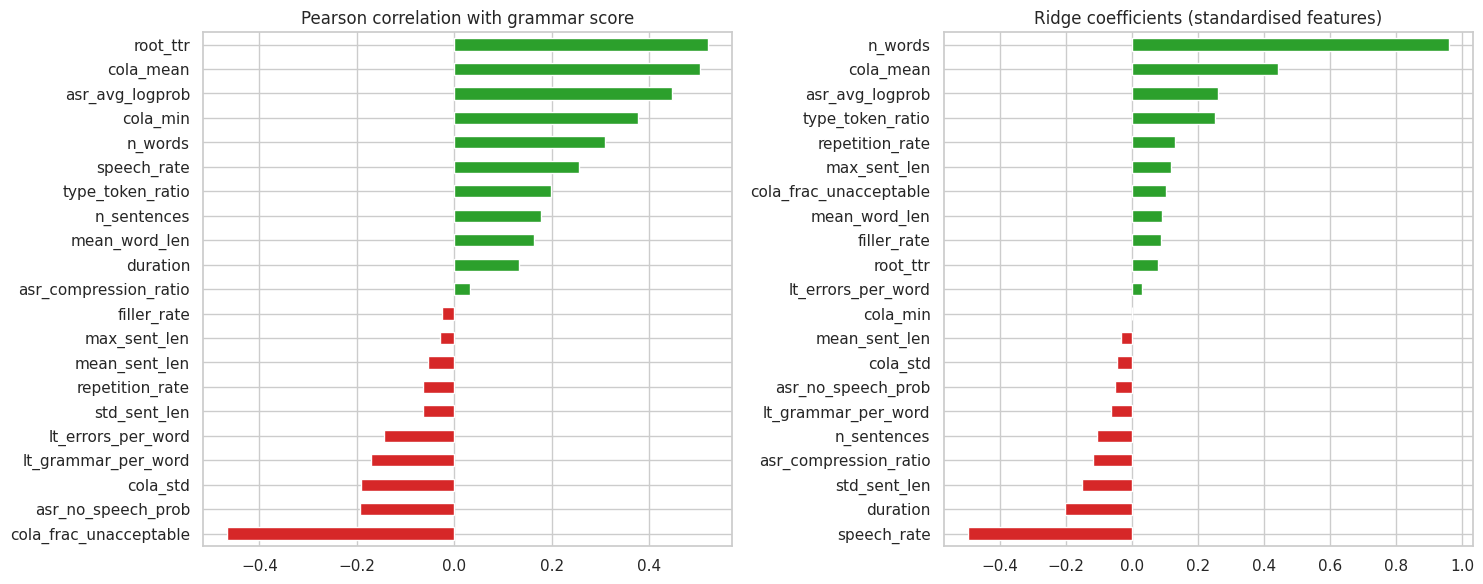

In [17]:
# Correlation of each interpretable feature with the score, and Ridge coefficients on these features alone.
corr = pd.Series({c: pearsonr(hand_train[c], y_train)[0] for c in hand_train.columns}).sort_values()
hand_model = Pipeline([("scaler", StandardScaler()), ("ridge", RidgeCV(alphas=ALPHAS))]).fit(hand_train, y_train)
coefs = pd.Series(hand_model[-1].coef_, index=hand_train.columns).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
corr.plot.barh(ax=axes[0], color=["tab:red" if v < 0 else "tab:green" for v in corr])
axes[0].set_title("Pearson correlation with grammar score")
coefs.plot.barh(ax=axes[1], color=["tab:red" if v < 0 else "tab:green" for v in coefs])
axes[1].set_title("Ridge coefficients (standardised features)")
plt.tight_layout(); plt.show()

**Interpretation.**
* Strongest positive correlations with the score: vocabulary range (`root_ttr`, r ≈ 0.52), average sentence
  acceptability from the CoLA model (`cola_mean`, r ≈ 0.50) and Whisper's confidence (`asr_avg_logprob`, r ≈ 0.45):
  clearer speech with more varied vocabulary and grammatical sentences scores higher.
* Strongest negative correlation: share of sentences the CoLA model judges ungrammatical
  (`cola_frac_unacceptable`, r ≈ −0.47). LanguageTool grammar errors per word are also negative (r ≈ −0.17).
* Coefficients of correlated features should not be read one by one: for example `n_words` and `speech_rate`
  carry almost the same information (words = rate × duration), so Ridge gives one a large positive weight and
  the other a negative one, even though both correlate positively with the score.

## 11. Cross-validated evaluation of the best feature set

,fold,RMSE,MAE,Pearson,Spearman,R2
0,1,0.5573,0.4301,0.8297,0.8250,0.6882
1,2,0.5313,0.4014,0.8473,0.8431,0.7167
2,3,0.5472,0.4158,0.8446,0.8391,0.7116
3,4,0.5485,0.4395,0.8511,0.8528,0.7233
4,5,0.4890,0.3644,0.8769,0.8625,0.7653


Text + both audio: CV RMSE 0.5352 | Pearson 0.8495
Per-fold RMSE 0.5347 ± 0.0272


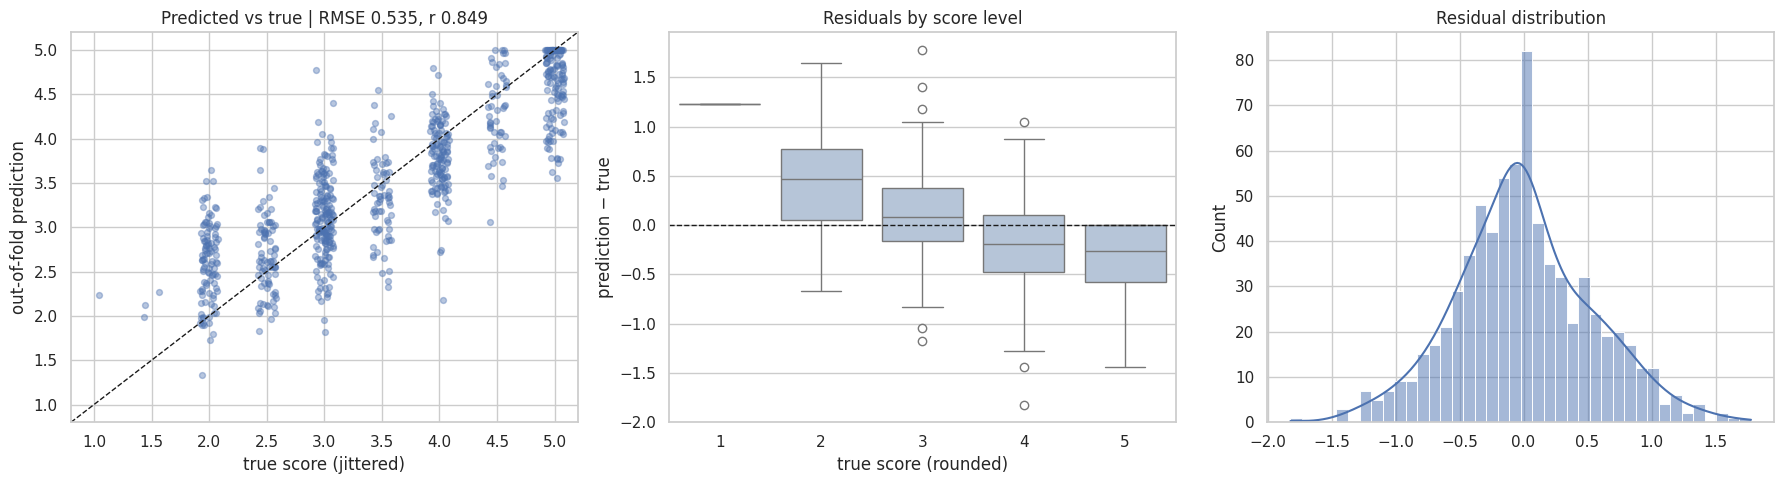

In [18]:
# Out-of-fold evaluation of the best feature set: per-fold metrics and diagnostic plots.
X_train, X_test, RANGES = build(FEATURE_SETS[BEST_SET])
oof = oof_by_set[BEST_SET]
cv_metrics = metrics(y_train, oof)

fold_df = pd.DataFrame([{"fold": k + 1, **metrics(y_train[va], oof[va])} for k, (tr, va) in enumerate(FOLDS)])
display(fold_df.round(4))
print(f"{BEST_SET}: CV RMSE {cv_metrics['RMSE']:.4f} | Pearson {cv_metrics['Pearson']:.4f}")
print(f"Per-fold RMSE {fold_df.RMSE.mean():.4f} ± {fold_df.RMSE.std():.4f}")

pd.DataFrame({FILE_COL: train_df[FILE_COL], "true": y_train, "oof_pred": oof,
              "transcript": tr_train.text}).to_csv(WORK_DIR / "oof_predictions.csv", index=False)

resid = oof - y_train
jitter = np.random.uniform(-0.08, 0.08, len(y_train))
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(y_train + jitter, oof, alpha=0.4, s=18)
lims = [CLIP_MIN - 0.2, CLIP_MAX + 0.2]
axes[0].plot(lims, lims, "k--", lw=1); axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].set_xlabel("true score (jittered)"); axes[0].set_ylabel("out-of-fold prediction")
axes[0].set_title(f"Predicted vs true | RMSE {cv_metrics['RMSE']:.3f}, r {cv_metrics['Pearson']:.3f}")
sns.boxplot(x=np.round(y_train).astype(int), y=resid, ax=axes[1], color="lightsteelblue")
axes[1].axhline(0, color="k", ls="--", lw=1)
axes[1].set_xlabel("true score (rounded)"); axes[1].set_ylabel("prediction − true")
axes[1].set_title("Residuals by score level")
sns.histplot(resid, bins=40, kde=True, ax=axes[2]); axes[2].set_title("Residual distribution")
plt.tight_layout(); plt.show()

**Cross-validated performance.** RMSE 0.535 (per-fold 0.535 ± 0.027), Pearson 0.850, R² 0.72.
The scatter plot follows the diagonal, the residuals are centred on zero and roughly symmetric, and the
per-fold results are consistent, so the estimate is stable. The residual box plot shows the main weakness:
low scores are over-predicted and high scores under-predicted, quantified below.

### Error analysis by score level

,clips,mean_prediction,rmse,share_of_total_error
true,,,,
1.0,1,2.231,1.231,0.007
1.5,3,2.129,0.639,0.006
2.0,102,2.610,0.751,0.275
2.5,79,2.683,0.468,0.083
3.0,174,3.104,0.478,0.189
3.5,64,3.321,0.511,0.080
4.0,124,3.792,0.438,0.114
4.5,52,4.286,0.504,0.063
5.0,133,4.628,0.539,0.184


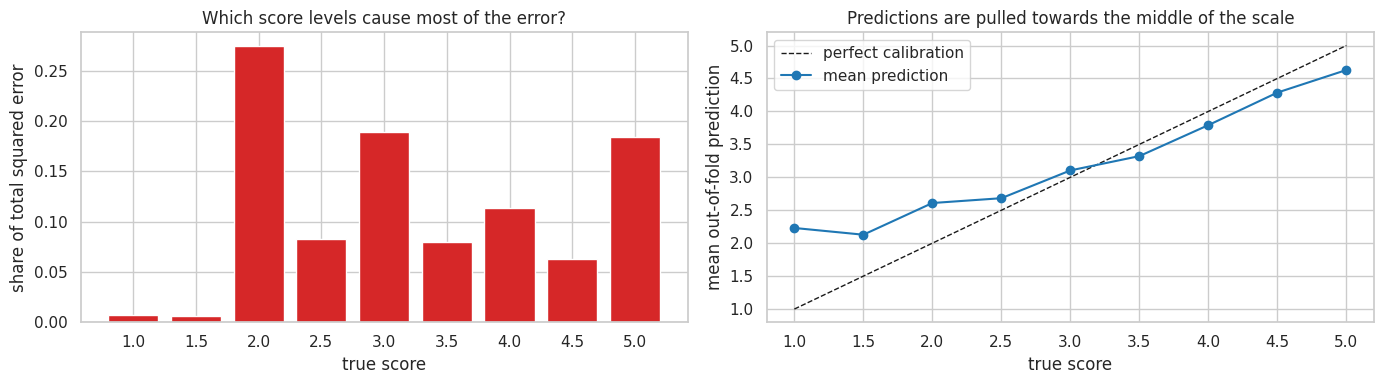

In [19]:
# Error analysis by score level: where does the remaining cross-validated error come from?
err = pd.DataFrame({"true": y_train, "pred": oof, "sq_err": (oof - y_train) ** 2})
by_level = err.groupby("true").agg(clips=("sq_err", "size"),
                                    mean_prediction=("pred", "mean"),
                                    rmse=("sq_err", lambda s: np.sqrt(s.mean())),
                                    share_of_total_error=("sq_err", "sum"))
by_level["share_of_total_error"] /= by_level["share_of_total_error"].sum()
display(by_level.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(by_level.index.astype(str), by_level.share_of_total_error, color="tab:red")
axes[0].set_xlabel("true score"); axes[0].set_ylabel("share of total squared error")
axes[0].set_title("Which score levels cause most of the error?")
axes[1].plot([1, 5], [1, 5], "k--", lw=1, label="perfect calibration")
axes[1].plot(by_level.index, by_level.mean_prediction, "o-", color="tab:blue", label="mean prediction")
axes[1].set_xlabel("true score"); axes[1].set_ylabel("mean out-of-fold prediction")
axes[1].set_title("Predictions are pulled towards the middle of the scale"); axes[1].legend()
plt.tight_layout(); plt.show()

**Where the error comes from.**
* Clips scored **2.0** (102 clips) are predicted at about **2.61** on average and cause **≈ 27 %** of all
  squared error; clips scored **5.0** are predicted at about **4.63** and cause **≈ 18 %**.
* The model is pulled towards the middle of the scale, typical for regression with regularisation and
  noisy labels.
* The largest errors (table below) are often fluent-sounding answers with generic, possibly memorised
  phrasing scored 2 (the rubric mentions "memorized sentence patterns"), and answers where Whisper's
  transcript is cleaner than the speech, so grammar mistakes are not visible to the text features.

In [20]:
# Largest errors: read the transcripts to see what the model gets wrong
worst_idx = np.argsort(np.abs(oof - y_train))[::-1][:8]
worst = pd.DataFrame({"true": y_train, "pred": oof.round(2), "error": (oof - y_train).round(2),
                      "transcript": tr_train.text}).iloc[worst_idx]
display(worst)

,true,pred,error,transcript
438,4.0,2.18,-1.82,"Playground has many children. There are many slides, see-so, and different kind of playing activities. The noise from the playground are coming from the children shouting and playing."
237,3.0,4.78,1.78,"Basically, here, uh, the crowded markets, uh, the markets should be crowded on Friday times. Uh, there are so many people in the markets. Uh, they might be selling the visitables, fruits, uh, and the household items, everything. Whenever we want to, uh, buy something, we will bargain there. People always, uh, people selling so many, like, parts, junk, foods, some bakery items and some food ite..."
559,2.0,3.64,1.64,This goal is important to me. The challenges I face are a lot. What motivates me to stay focused is my determination and focus.
502,2.0,3.52,1.52,"Well, what I can, what I can describe on a school playground could be, uh, many kids playing around with a lot of toys that are given from the school. Um, I can see also lots of sports that they can play, like volleyball, basketball, or even football, that is one of the most popular sport that is here in Peru. I think that the enjoyment in this place is kind of interesting because people's kid..."
74,2.0,3.52,1.52,"My favorite hobby is listening to songs. Of course, mobile and earphones are very mandatory for listening music. Whenever I feel sad, low, or happy, I like to listen songs. It depends on my mood. When I'm happy, I listen to the, like, rap songs and many different enjoying songs. And when it comes to my sad mood, I listen to the hard-wracking song. And also I like to listen when I am alone or w..."
655,4.5,3.05,-1.45,"My goal in life is to save the planet. There is a serious need that we human beings, we need to save our Earth. Because we are facing a serious crisis of climate change. There's floods and everything, so... My goal is to educate my community on how we can recycle, on how we can change what we do things and on how we can make our planet a better place for our future children. They have to enjoy..."
212,5.0,3.56,-1.44,"There were slides and monkey bars and swing sets. They were all, all colorful. It was a, it was like a big jungle gym. You hear laughter, kids running, chasing each other, laughing, some kids crying, a lot of kids smiling. There was a lot of, it was a big... there's a horde of kids playing on the monkey bars. They're running around. A lot of kids waiting in line for the slide. Kids pushing eac..."
661,3.0,4.41,1.41,"I consider the best day of my life to be when I went on a trip to a tropical paradise. My morning started early with birds chirping and waves crashing again for sure and the sun shining through the window. I spent the day lounging on the beach, lapping under the sun and swimming in a crystal pier water. In the evening, I watched the sunset from a rooftop bar while sleeping on a fresh refreshin..."


## 12. Final model and **training RMSE** (required)
The final Ridge model is fitted on all 732 training clips (with `alpha` chosen by cross-validation on the
full training set). Its error on those same clips is the **training RMSE**, reported below as required.
It measures how well the model fits data it has seen, so it is optimistic; the cross-validated RMSE in
Section 11 is the realistic estimate of performance on new recordings.

In [21]:
# Fit the final model on all training clips and report the TRAINING RMSE (required) next to the CV RMSE.
final_model = make_model(RANGES).fit(X_train, y_train)
FINAL_ALPHA = float(final_model[-1].alpha_)
train_pred = np.clip(final_model.predict(X_train), CLIP_MIN, CLIP_MAX)
train_metrics = metrics(y_train, train_pred)

print(f"Feature set      : {BEST_SET} ({X_train.shape[1]} features), alpha = {FINAL_ALPHA:.4g}")
print(f"TRAINING RMSE    : {train_metrics['RMSE']:.4f}   (Pearson {train_metrics['Pearson']:.4f})")
print(f"Cross-val RMSE   : {cv_metrics['RMSE']:.4f}   (Pearson {cv_metrics['Pearson']:.4f})")
print(f"Baseline RMSE    : {baseline['RMSE']:.4f}")
joblib.dump({"model": final_model, "feature_set": BEST_SET, "blocks": FEATURE_SETS[BEST_SET]},
            WORK_DIR / "ridge_text_audio.joblib")

Feature set      : Text + both audio (4629 features), alpha = 2.512
TRAINING RMSE    : 0.3328   (Pearson 0.9488)
Cross-val RMSE   : 0.5352   (Pearson 0.8495)
Baseline RMSE    : 1.0137


['/kaggle/working/ridge_text_audio.joblib']

> **Training RMSE = 0.3328** (Pearson 0.949) · Cross-validated RMSE = 0.5352 (Pearson 0.850) ·
> Baseline RMSE = 1.0137.
>
> The gap between training and CV error (0.33 vs 0.54) is expected with 4,629 features and 732 clips; the
> Ridge penalty (`alpha` = 2.51) keeps it under control, and the CV error is what the model achieves on
> unseen recordings.

## 13. Test predictions and submission file
`sample_submission.csv` only illustrates the format (columns `filename`, `label`); its file names do not
match `test.csv`, so the submission is built from `test.csv`. Row order is preserved throughout.

In [22]:
# Predict the 216 test clips and write submission.csv (columns: filename, label).
test_pred = np.clip(final_model.predict(X_test), CLIP_MIN, CLIP_MAX)
submission = pd.DataFrame({"filename": test_df[FILE_COL].values, "label": test_pred})
submission.to_csv(WORK_DIR / "submission.csv", index=False)
print(f"saved {WORK_DIR / 'submission.csv'} | {len(submission)} rows")
display(submission.head())

saved /kaggle/working/submission.csv | 216 rows


,filename,label
0,audio_128.wav,3.041155
1,audio_156.wav,4.103238
2,audio_19.wav,4.537702
3,audio_108.wav,1.837521
4,audio_206.wav,2.021394


## 14. Results summary

In [23]:
# Results summary table and a JSON record of the configuration and metrics.
summary = pd.DataFrame({"Baseline (predict mean)": baseline,
                        "Training (fit on all train)": train_metrics,
                        f"5-fold CV: {BEST_SET}": cv_metrics}).T[["RMSE", "Pearson", "MAE", "Spearman", "R2"]].round(4)
display(summary)

config = {"asr": f"whisper {WHISPER_MODEL}", "text_embedding": TEXT_EMB_MODEL, "grammar_model": COLA_MODEL,
          "languagetool": "lt_errors_per_word" in hand_train.columns,
          "audio": f"{W2V_MODEL} layer {AUDIO_LAYER}, full clip, mean+std",
          "whisper_encoder": f"{WENC_MODEL} layer {WHISPER_ENC_LAYER}" if USE_WHISPER_ENC else None,
          "dropped_score0_clips": bool(DROP_ZERO_LABELS), "n_train": int(len(y_train)),
          "feature_set": BEST_SET, "n_features": int(X_train.shape[1]), "ridge_alpha": FINAL_ALPHA}
print(json.dumps(config, indent=2))
with open(WORK_DIR / "results.json", "w") as f:
    json.dump({"config": config, "metrics": summary.to_dict(orient="index"),
               "ablation": ablation_df.round(4).to_dict(orient="index")}, f, indent=2, default=str)

,RMSE,Pearson,MAE,Spearman,R2
Baseline (predict mean),1.0137,NaN,0.8760,NaN,0.0000
Training (fit on all train),0.3328,0.9488,0.2565,0.9466,0.8922
5-fold CV: Text + both audio,0.5352,0.8495,0.4102,0.8473,0.7212


{
  "asr": "whisper small.en",
  "text_embedding": "sentence-transformers/all-mpnet-base-v2",
  "grammar_model": "textattack/roberta-base-CoLA",
  "languagetool": true,
  "audio": "facebook/wav2vec2-base layer 8, full clip, mean+std",
  "whisper_encoder": "openai/whisper-small layer 9",
  "dropped_score0_clips": true,
  "n_train": 732,
  "feature_set": "Text + both audio",
  "n_features": 4629,
  "ridge_alpha": 2.5118864315095824
}


## 15. Report

### Problem framing
The labels are ordered mean opinion scores (1–5, steps of 0.5) and the leaderboard uses RMSE and Pearson
correlation, so the task is treated as **regression** with continuous outputs. Rounding the predictions to
the nearest 0.5 was checked and makes RMSE worse (0.535 → 0.555), because a continuous prediction is the
best guess under uncertainty.

### Preprocessing
1. **Audio:** resampled to 16 kHz mono, leading and trailing silence trimmed (30 dB threshold),
   peak-normalised.
2. **Transcription:** Whisper `small.en`, prompted with a disfluent example so it keeps fillers and errors,
   with each 30 s window decoded independently to avoid repeated hallucinations.
3. **Training data:** the 37 score-0 clips (outside the rubric, one separate batch, nothing similar in the
   test set) are excluded, leaving **732 clips**. Predictions are clipped to [1, 5].
4. **Missing values** in the interpretable features (for example an empty transcript) are filled with
   the training median.

### Pipeline architecture
| Block | Model / method | Features |
|---|---|---|
| Audio 1 | wav2vec2-base (self-supervised), layer 8, whole clip, mean + std over time | 1,536 |
| Audio 2 | Whisper-small encoder, layer 9 (chosen by CV), 20 s chunks, padding removed, mean + std | 1,536 |
| Grammar | RoBERTa fine-tuned on CoLA: per-sentence acceptability (mean, min, std, share < 0.5) and transcript embedding; LanguageTool grammar errors per word | 6 + 768 |
| Fluency & complexity | speech rate, words, sentences, sentence length, vocabulary diversity, fillers, repetitions, duration, Whisper confidence | 15 |
| Text meaning | all-mpnet-base-v2 sentence embedding | 768 |

All 4,629 features are standardised; each block is divided by √(block size) so that every block carries the
same total weight. **Ridge regression** (L2-penalised linear model) maps them to the score; `alpha` is chosen
by `RidgeCV` inside each training fold, so the out-of-fold scores are honest.

### Evaluation
Stratified 5-fold cross-validation on the 732 clips (stratified on the rounded score).

| | RMSE | Pearson | MAE | R² |
|---|---|---|---|---|
| Baseline (predict mean) | 1.0137 | – | 0.876 | 0.000 |
| **Training RMSE (required)** | **0.3328** | 0.949 | 0.257 | 0.892 |
| **5-fold CV** | **0.5352** | 0.850 | 0.410 | 0.721 |
| Public leaderboard | 0.3846 | | | |

The leaderboard RMSE is lower than CV because the test set contains no score-0-type clips and its scores
are less spread out.

### How the score improved (development history)
| Model | Public leaderboard |
|---|---|
| wav2vec2 audio embeddings + Ridge | 0.4742 |
| Whisper encoder embeddings + SVR | 0.4722 |
| + transcripts and grammar features (Ridge) | 0.4144 |
| **+ Whisper encoder block, score-0 clips removed (this notebook)** | **0.3846** |

### Findings
* **Audio carries most of the signal**; the Whisper encoder is the strongest single block (CV 0.555).
* **Text adds complementary grammar information** (0.555 → 0.535 with all blocks).
* **Grammar-specific text features beat general ones**: CoLA embedding 0.644 vs sentence embedding 0.778.
* Interpretable features agree with the rubric: grammatical sentences, varied vocabulary and clear speech
  score higher; sentences judged ungrammatical and LanguageTool errors score lower.
* Remaining error concentrates on the extremes (scores 2 and 5), where predictions are pulled towards
  the middle.

### Limitations
* Text features depend on transcription quality: words Whisper mishears or silently corrects change them.
* Pooling over time (mean + std) discards word order in the audio embeddings.
* CoLA was built from written sentences; spoken language is less formal, so its scores are noisy for speech.
* Human ratings are averages of several raters, so some label noise is unavoidable.

### Possible improvements
* Larger Whisper model (`medium.en`) for more faithful transcripts.
* Pause features from word-level timestamps; averaging Whisper layers 8–11.
* Dropping the sentence embedding and fluency features gives a simpler model with a slightly lower CV RMSE
  (0.530), found in a later ablation.